<a href="https://colab.research.google.com/github/halxbrown/nmt-en-es/blob/main/notebooks/nmt_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English → Spanish Neural Machine Translation
## Custom Transformer in PyTorch — Track A

**Natural Language Processing — Final Project**

This notebook runs the complete pipeline: data preparation, model construction,
training, evaluation, and export. The model implementation itself lives in the
GitHub repository (`src/`) and is cloned in Section 0 — Colab is used only as a
GPU runtime, not as the place the code is written.

| Section | Milestone | Runtime |
|---|---|---|
| 0 | Setup — GPU, Drive, clone | ~1 min |
| 1 | Data pipeline, tokenizer, DataLoader | ~5 min |
| 2 | Model construction and mask verification | ~1 min |
| 3 | Training both capacity presets | ~50 min |
| 4 | Held-out test evaluation and error analysis | ~10 min |
| 5 | Length-penalty tuning | ~15 min |
| 6 | Export for local inference | ~1 min |

**Before running:** Runtime → Change runtime type → **T4 GPU** → Save.

Checkpoints are written to Google Drive after every epoch. If the session is
killed, re-running the training cell resumes from the last completed epoch
rather than starting over.

---
# 0. Setup

In [8]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07


In [9]:
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("!! No GPU. Runtime -> Change runtime type -> T4 GPU, then rerun.")

torch 2.11.0+cu128 | CUDA available: True


### 0.1 Mount Drive

Colab wipes local storage when a session ends. Checkpoints must live in Drive.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/nmt-en-es'
CKPT_DIR = f'{DRIVE_ROOT}/checkpoints'
!mkdir -p "{CKPT_DIR}"
print('checkpoints ->', CKPT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints -> /content/drive/MyDrive/nmt-en-es/checkpoints


### 0.2 Clone the project

All model code is version-controlled. Colab clones it rather than defining it
inline, so the code that trains here is byte-identical to the code that runs
locally.

In [11]:
!git clone https://github.com/halxbrown/nmt-en-es.git /content/nmt-en-es
%cd /content/nmt-en-es
!ls

Cloning into '/content/nmt-en-es'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 123 (delta 25), reused 108 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 12.40 MiB | 29.60 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/nmt-en-es
artifacts	 README.md	    run_milestone3.py  sweep_length_penalty.py
config.py	 reports	    run_milestone4.py  translate.py
export_model.py  requirements.txt   screenshots        verify_decoding.py
models		 run_milestone1.py  setup_local.py
notebooks	 run_milestone2.py  src


In [12]:
!pip install -q sentencepiece sacrebleu rouge-score 'datasets>=3.0'
# torch is preinstalled and CUDA-matched -- do not reinstall it.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 13.6 MB/s eta 0:00:00


---
# 1. Milestone 1 — Data Pipeline

Downloads OPUS-100 `en-es`, applies eight cleaning filters, samples 100,000
pairs, trains a joint 16k SentencePiece BPE vocabulary, and builds the
DataLoader with dynamic padding and length bucketing.

**What to look for in the output:**
- The filter table (16.46% dropped) — Table 1 of the report
- Fertility 1.49 on both sides, UNK rate 0.0000%
- Padding efficiency 22.8% → 78.0% (3.42× fewer wasted attention cells)
- Four mask verification PASSes

In [13]:
!python run_milestone1.py --force


1. DATA PREPARATION

[train] streaming Helsinki-NLP/opus-100:en-es ...
README.md: 100% 65.4k/65.4k [00:00<00:00, 106MB/s]

en-es/test-00000-of-00001.parquet: downloading bytes:   0% 0.00/237k [00:00<?, ?B/s]
en-es/test-00000-of-00001.parquet: downloading bytes: 100% 237k/237k [00:00<00:00, 270kB/s, 23.4kB/s  ]
en-es/test-00000-of-00001.parquet: reconstructing file: 100% 237k/237k [00:00<00:00, 270kB/s, 23.3kB/s  ]

en-es/train-00000-of-00001.parquet: downloading bytes: 100% 99.4M/99.6M [00:01<00:00, 139MB/s, 6.17MB/s  ] 
en-es/train-00000-of-00001.parquet: downloading bytes: 100% 99.4M/99.4M [00:01<00:00, 63.9MB/s, 9.52MB/s  ]
en-es/train-00000-of-00001.parquet: reconstructing file: 100% 99.6M/99.6M [00:01<00:00, 64.1MB/s, 9.59MB/s  ]

en-es/validation-00000-of-00001.parquet: downloading bytes:   0% 0.00/238k [00:00<?, ?B/s]
en-es/validation-00000-of-00001.parquet: downloading bytes: 100% 238k/238k [00:00<00:00, 265kB/s, 23.3kB/s  ]
en-es/validation-00000-of-00001.parquet: reconstruct

---
# 2. Milestone 2 — Model & Mask Verification

Builds the Transformer and verifies correctness **behaviourally** rather than
by inspection. A masking bug degrades translation quality without raising an
exception, so structural assertions alone are not sufficient.

**What to look for:**
- 37,619,712 parameters; embedding and output projection share storage
- Initial loss 10.27 vs ln(16000)=9.68 — the excess is the tied-embedding copy
  bias, explained in Section 3.3 of the report
- **Causal test: `0.000e+00`** before the corrupted position — no information
  flows backwards in time
- **Padding test: ~`5.7e-06`** — GPU float non-associativity, four orders of
  magnitude below a real leak
- Single-batch overfit: loss falls 10.27 → ~1.4

In [14]:
!python run_milestone2.py --steps 60


1. MODEL
device: cuda   vocab: 16,000
d_model=512 heads=8 d_ff=2048 layers=4+4 dropout=0.2 pre_norm=True

decoder         16,816,128
encoder         12,609,536
embed            8,192,000
enc_norm             1,024
dec_norm             1,024
--------------------------
TOTAL           37,619,712

  [PASS] embedding / generator weights share storage (3-way tying: True)

2. SINGLE-BATCH FORWARD PASS
  src              (64, 13)
  decoder_input    (64, 13)
  logits           (64, 13, 16000)
  [PASS] logits are (batch, tgt_len, vocab) and all finite
  encoder self-attn (64, 8, 13, 13)  (B, heads, S, S)
  cross-attn        (64, 8, 13, 13)  (B, heads, T, S)
  [PASS] attention rows sum to 1

3. LOSS AT INITIALISATION
  observed loss   10.2690
  ln(vocab)       9.6803   (loss of a perfectly uniform model)
  excess          +0.5886

  copy bias at init (explains the excess):
    mean logit, all tokens       -0.005
    mean logit, input token y_t  +8.032  <- residual stream + tying
    mean logit,

---
# 3. Milestone 3 — Training

Trains two capacity presets with **identical regularization**, so the ablation
isolates capacity rather than confounding it with dropout.

| | base | small |
|---|---:|---:|
| Layers | 4 + 4 | 3 + 3 |
| `d_ff` | 2048 | 1024 |
| Parameters | 37.6M | 24.0M |
| Dropout | 0.2 | 0.2 |

AdamW, peak LR 5e-4, 2000-step warmup then cosine decay, label smoothing 0.1,
fp16 autocast, early stopping patience 3.

**~50 minutes.** Checkpoints save to Drive every epoch — if the session dies,
just re-run this cell.

In [15]:
!python run_milestone3.py --preset both --epochs 20 --checkpoint-dir "{CKPT_DIR}"


PRESET 'BASE'
37,619,712 parameters | layers 4+4 | d_ff 2048 | dropout 0.2
resumed base from epoch 20 (best val 3.4754)

training 'base': 20 epochs x 1,563 steps = 31,260 total | amp=True | device=cuda
  restored best checkpoint for decoding

DECODING -- base (500 validation sentences)
    greedy: 32/500
    greedy: 352/500
  greedy       BLEU 25.05  chrF 49.11  ROUGE-L 51.02  (5.6s, 89.6/s)
    beam: 32/500
    beam: 352/500
  beam k=5     BLEU 26.32  chrF 49.88  ROUGE-L 51.83  (25.3s, 19.8/s)

  sample translations:
    SRC    I don't even remember what the fight was about.
    REF    No recuerdo por qué fue la pelea.
    greedy Ni siquiera recuerdo lo que la pelea estaba.
    beam   Ni siquiera recuerdo lo de la pelea.

    SRC    Here are the sites of each of those that have taken place:
    REF    Estos son los sitios en que cada Congreso ha tenido lugar:
    greedy Aquí están los sitios de cada uno de esos que se han llevado a cabo:
    beam   Aquí están los sitios de cada uno d

### 3.1 Decoder correctness

Three properties BLEU cannot establish. A subtly broken beam search still
produces fluent output and a plausible score.

1. `beam(k=1, α=0)` must reproduce greedy **token-for-token** — with one beam
   there is nothing to compare, so it must degenerate to argmax
2. `beam(k=5)` must find sequences of **higher model log-probability** than
   greedy — that is beam search's entire purpose
3. Mean hypothesis length must be **non-decreasing in α**

In [16]:
%cd /content/nmt-en-es
!git pull
!python verify_decoding.py --preset base  --checkpoint-dir "{CKPT_DIR}"
!python verify_decoding.py --preset small --checkpoint-dir "{CKPT_DIR}"

/content/nmt-en-es
Already up to date.
loaded /content/drive/MyDrive/nmt-en-es/checkpoints/base/best.pt
probing 8 validation sentences, source lengths [9, 11, 13, 16, 20, 27, 42, 128] subwords

1. beam(k=1, alpha=0) must be IDENTICAL to greedy
   With one beam there is nothing to compare against, so beam search
   degenerates to argmax at every step. Any difference means the beam
   bookkeeping -- reordering, scoring, or termination -- is wrong.

   [PASS] 8/8 sequences match

2. beam(k=5) must find sequences of HIGHER log-probability
   This is beam search's entire purpose: approximate the best
   SEQUENCE rather than a chain of locally-best tokens. If it does
   not beat greedy on model score, it is not searching.

   greedy mean log-prob -15.005  ->  beam -11.230
   beam strictly better on 4/8; equal or better on 8/8
   [PASS] beam never scores below greedy

3. length penalty must lengthen output monotonically
   Sequence log-probability is a sum of negative terms, so raw beam
   se

### 3.2 Learning curves

Neither model triggered early stopping — validation loss improved monotonically
through epoch 19. Note that the learning rate reached its cosine floor exactly
as the curves flattened, so convergence cannot be distinguished from the
schedule ending.

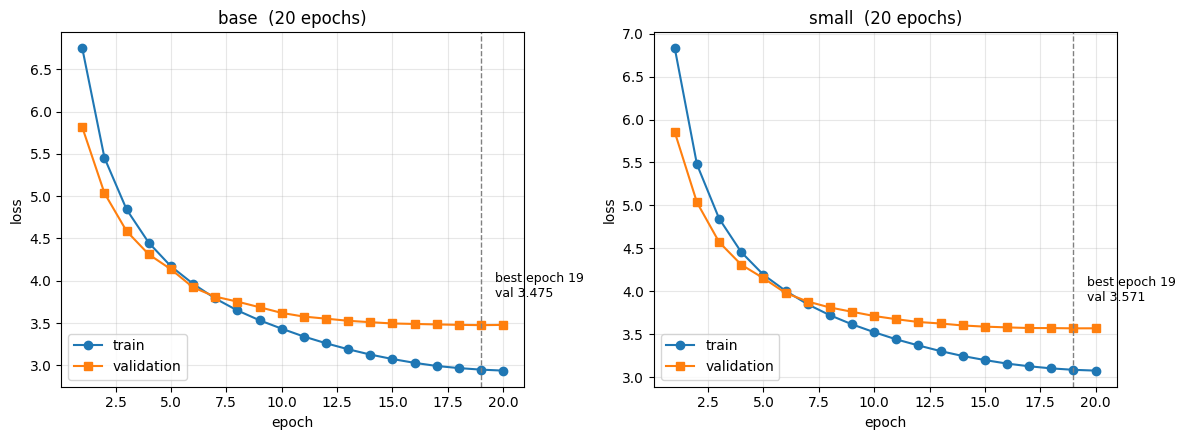

In [17]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, preset in zip(axes, ['base', 'small']):
    p = Path(CKPT_DIR) / preset / 'history.json'
    if not p.exists():
        ax.set_title(f'{preset}: no history found')
        continue
    h = json.loads(p.read_text())
    ep = [r['epoch'] for r in h]
    ax.plot(ep, [r['train_loss'] for r in h], 'o-', label='train')
    ax.plot(ep, [r['val_loss'] for r in h], 's-', label='validation')
    best = min(h, key=lambda r: r['val_loss'])
    ax.axvline(best['epoch'], ls='--', c='grey', lw=1)
    ax.annotate(f"best epoch {best['epoch']}\nval {best['val_loss']:.3f}",
                (best['epoch'], best['val_loss']),
                textcoords='offset points', xytext=(10, 20), fontsize=9)
    ax.set_title(f"{preset}  ({len(h)} epochs)")
    ax.set_xlabel('epoch'); ax.set_ylabel('loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
Path('artifacts').mkdir(exist_ok=True)
plt.savefig('artifacts/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4. Milestone 4 — Held-Out Test Evaluation

Milestone 3's numbers came from the **validation** set, which selected the
checkpoint, so they are optimistically biased. Everything here runs on `test`,
untouched until now.

Includes paired-bootstrap significance testing (Koehn, 2004), BLEU bucketed by
sentence length, heuristic error categorisation, and cross-attention maps.

**What to look for:**
- Test BLEU slightly below validation — that gap is the selection bias
- Every comparison carries a 95% CI and p-value
- Length ratio ≈ 0.92 in *every* bucket — a uniform brevity bias

In [18]:
!python run_milestone4.py --preset both --checkpoint-dir "{CKPT_DIR}"


MILESTONE 4 -- HELD-OUT TEST SET
device cuda | 2,000 test sentences | never seen during training or checkpoint selection

BASE -- 37,619,712 params, val loss 3.4754
  greedy       BLEU  24.82  chrF  49.67  ROUGE-L  49.64  (91.1/s)
  beam k=5     BLEU  25.88  chrF  50.49  ROUGE-L  50.84  (18.0/s)

  paired bootstrap (1000 resamples):
    beam - greedy = +1.06 BLEU  95% CI [+0.69, +1.46]  p = 0.0  -> significant

  BLEU by source length (beam):
    bucket          n    BLEU  len ratio
    0-9          1103   26.29      0.926
    10-19         518   27.48      0.933
    20-29         196   25.81      0.926
    30-49         146   25.79      0.906
    50+            37   21.03      0.866

  heuristic error categories (beam):
    lexical_semantic        1605   80.25%
    untranslated_entity      218    10.9%
    truncation               122     6.1%
    over_generation           82     4.1%
    repetition                 6     0.3%

  15 worst sentences -> /content/nmt-en-es/artifacts/fail

### 4.1 Attention maps

Cross-attention from the final decoder layer, averaged over heads. The diagonal
band is emergent word alignment — nothing in the loss function asked for it.

artifacts/attention_base_1.png


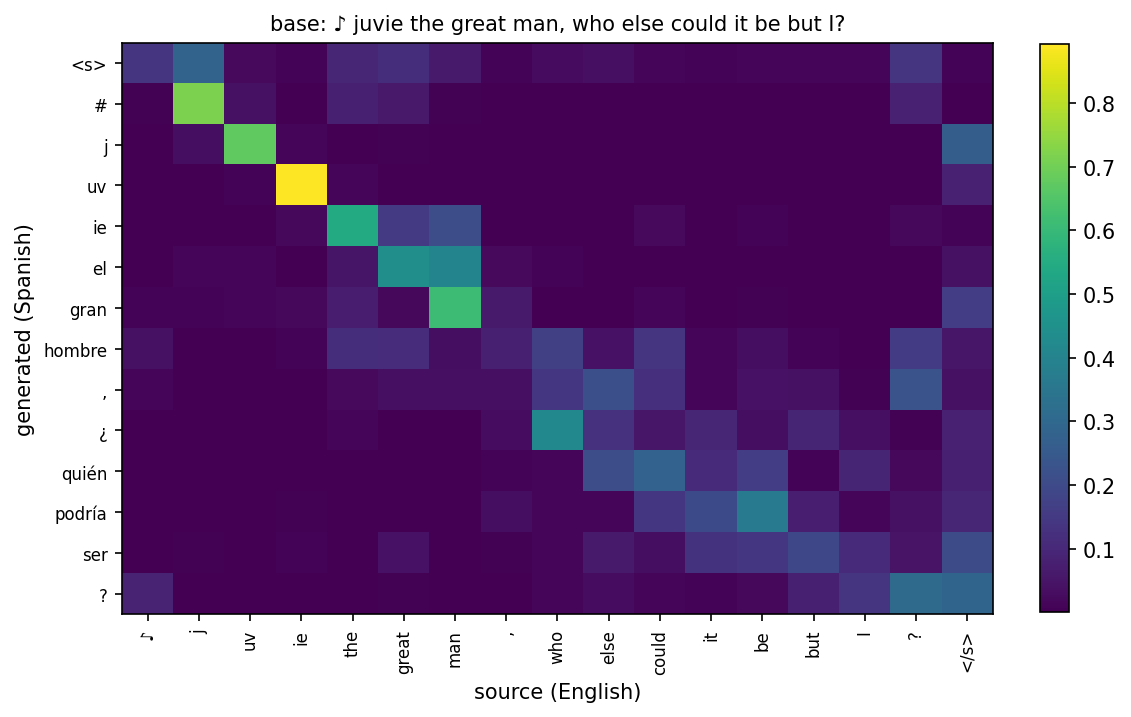

artifacts/attention_base_2.png


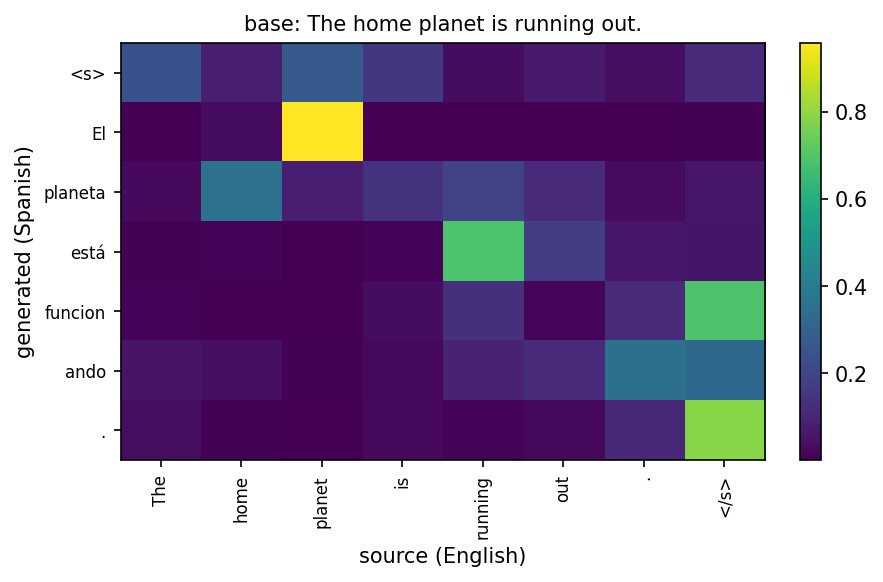

artifacts/attention_small_1.png


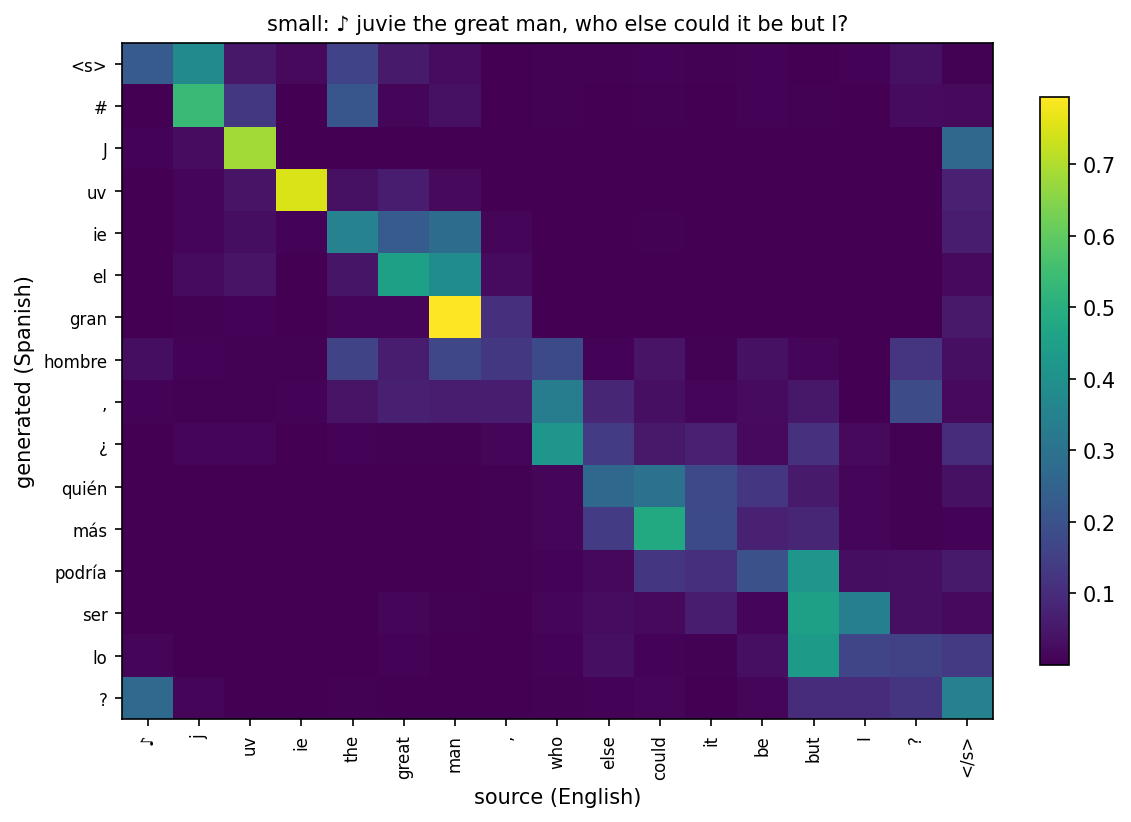

artifacts/attention_small_2.png


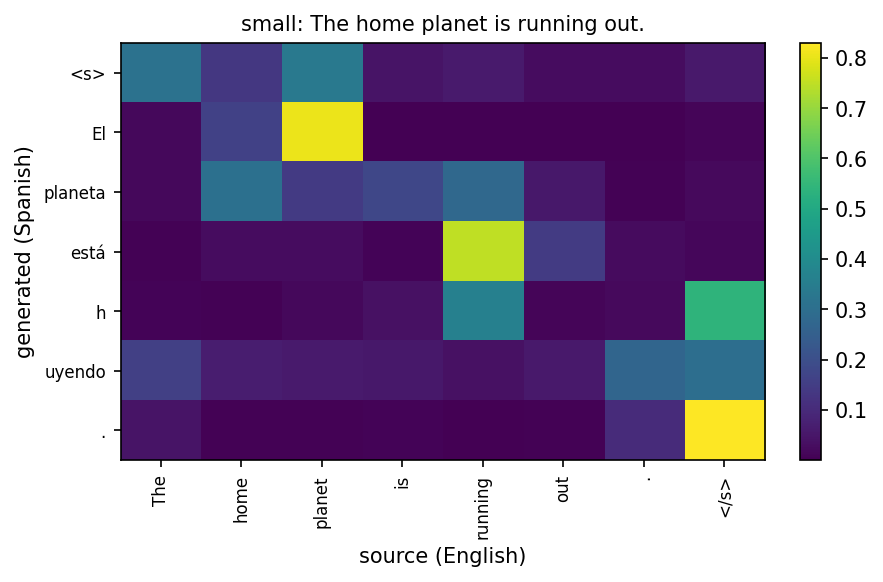

In [19]:
import glob
from IPython.display import Image, display
for p in sorted(glob.glob('artifacts/attention_*.png')):
    print(p)
    display(Image(filename=p, width=780))

### 4.2 Worst-scoring sentences

Ranked by sentence chrF. Tags are heuristic hints; the report quotes sentences
that were read individually.

In [20]:
from IPython.display import Markdown, display
display(Markdown(open('artifacts/failures_base.md', encoding='utf-8').read()))

# Worst test sentences -- base (beam k=5)

Ranked by sentence chrF. Categories are heuristic hints; read the
sentences before citing them.


## #1138  chrF 0.89  [untranslated_entity]  len_ratio 0.6
- **SRC** The Corpse Bride
- **REF** "EL CADÁVER DE LA NOVIA"
- **HYP** El cadáver Bride
- untranslated: Bride

## #1482  chrF 1.03  [untranslated_entity]  len_ratio 0.71
- **SRC** COMMON ACTION KEY TO NEW JOBS
- **REF** LA ACTUACIÓN COMÚN, CLAVE PARA CREAR EMPLEO
- **HYP** Vayan a ver a KEY.
- untranslated: KEY

## #1083  chrF 1.04  [truncation]  len_ratio 0.11
- **SRC** I Bo? i ? .
- **REF** Dale a tu novio un abrazo de mi parte
- **HYP** ¿Bo?

## #355  chrF 1.31  [truncation]  len_ratio 0.11
- **SRC** [ Mouthing Words ]
- **REF** No podían estar juntos, pero tampoco soportaban estar separados.
- **HYP** Vale.

## #680  chrF 1.6  [lexical_semantic]  len_ratio 1.43
- **SRC** United Kingdom of Great Britain and Northern Ireland: amendment
- **REF** PROMOCIÓN Y PROTECCIÓN DE LOS DERECHOS HUMANOS
- **HYP** Reino Unido de Gran Bretaña e Irlanda del Norte: enmienda

## #1468  chrF 1.85  [truncation]  len_ratio 0.5
- **SRC** - Shake.
- **REF** - - Agitar .
- **HYP** - ¡Buenos!

## #89  chrF 3.31  [truncation]  len_ratio 0.17
- **SRC** Giotto a.k.a.
- **REF** Posee el anillo de la lluvia.
- **HYP** Mucha.

## #1218  chrF 3.51  [truncation, untranslated_entity]  len_ratio 0.29
- **SRC** - [man] Woolsley?
- **REF** - Le irá peor en un juicio.
- **HYP** - ¿Woolsley?
- untranslated: Woolsley

## #1114  chrF 4.39  [lexical_semantic]  len_ratio 0.62
- **SRC** I'm not leaving you with him.
- **REF** La delataría a la primera, ¿no lo ve?
- **HYP** No te voy con él.

## #1991  chrF 4.72  [lexical_semantic]  len_ratio 0.67
- **SRC** Oh, get this.
- **REF** Ah, y fíjate:
- **HYP** Mira esto.

## #1370  chrF 4.73  [lexical_semantic]  len_ratio 0.67
- **SRC** Here, finger bowl.
- **REF** Toma, una palangana para las manos.
- **HYP** Aquí, conejones de dedo.

## #752  chrF 5.19  [truncation]  len_ratio 0.4
- **SRC** I'm a big man- - I need a big car! It's who I am!
- **REF** ¡Puedes tener perfección portátil en la palma de tu mano!
- **HYP** ¡Soy un gran hombre!

## #83  chrF 5.21  [lexical_semantic]  len_ratio 1.4
- **SRC** Whatever happens to them is on you!
- **REF** - Déjeme ir, por favor.
- **HYP** ¡Lo que les pasa es en ti!

## #1614  chrF 5.6  [truncation]  len_ratio 0.5
- **SRC** [Slow pop music playing]
- **REF** [Música pop lento jugando]
- **HYP** Vamos, chicos.

## #968  chrF 5.62  [truncation]  len_ratio 0.5
- **SRC** He is uncouth. He got scared.
- **REF** Es un tosco y se asustó.
- **HYP** El tiene miedo.

---
# 5. Length-Penalty Tuning

Section 4.5 of the report. The model under-generates by ~8% at every sentence
length, and BLEU penalises that through the brevity penalty.

α is swept on **validation** and only the winning value is applied to test.
Tuning a decoding hyperparameter by test BLEU would contaminate the test set
exactly as selecting a checkpoint on test would.

**What to look for:** the validation curve rises monotonically across the whole
range, but the spread above α≈1.8 is smaller than the sampling noise — and the
validation argmax transfers *worse* to test than a smaller value does. A
monotonically improving tuning curve is not evidence that the largest value is
best.

In [21]:
!python sweep_length_penalty.py --preset base --alphas 0.6 1.0 1.4 1.8 2.2 2.6 3.0 3.5 4.0 --checkpoint-dir "{CKPT_DIR}"

loaded /content/drive/MyDrive/nmt-en-es/checkpoints/base/best.pt | device cuda

sweeping alpha on 1,000 VALIDATION sentences
   alpha     BLEU   len ratio  seconds
  ------------------------------------
     0.6    25.85       0.892       61
     1.0    26.16       0.909       58
     1.4    26.26       0.926       58
     1.8    26.32       0.941       59
     2.2    26.37       0.949       59
     2.6    26.57       0.957       59
     3.0    26.59       0.962       59
     3.5    26.69       0.967       59
     4.0    26.70       0.972       59

best on validation: alpha=4.0 (BLEU 26.7, length ratio 0.972)

applying alpha=4.0 once to 2,000 TEST sentences

  alpha=0.6 (original): BLEU 25.88  length ratio 0.918
  alpha=4.0 (tuned):    BLEU 26.24  length ratio 0.991

  delta +0.36 BLEU  95% CI [+0.02, +0.63]  p = 0.021
  -> significant

written to /content/nmt-en-es/artifacts/length_penalty_sweep_base.json


In [22]:
!python sweep_length_penalty.py --preset small --alphas 0.6 1.0 1.4 1.8 2.2 --checkpoint-dir "{CKPT_DIR}"

loaded /content/drive/MyDrive/nmt-en-es/checkpoints/small/best.pt | device cuda

sweeping alpha on 1,000 VALIDATION sentences
   alpha     BLEU   len ratio  seconds
  ------------------------------------
     0.6    24.64       0.882       39
     1.0    24.91       0.897       37
     1.4    25.23       0.918       38
     1.8    25.33       0.932       38
     2.2    25.34       0.946       37

best on validation: alpha=2.2 (BLEU 25.34, length ratio 0.946)

applying alpha=2.2 once to 2,000 TEST sentences

  alpha=0.6 (original): BLEU 24.87  length ratio 0.911
  alpha=2.2 (tuned):    BLEU 25.4  length ratio 0.974

  delta +0.53 BLEU  95% CI [+0.29, +0.78]  p = 0.0
  -> significant

written to /content/nmt-en-es/artifacts/length_penalty_sweep_small.json


---
# 6. Export for Local Inference

`best.pt` carries AdamW's two moment tensors per parameter plus scheduler state
and epoch history — roughly 340 MB, where the weights alone are 113 MB.
Inference needs none of it.

Download `base_inference.pt` from Drive into the local `models/` folder, then
run `python translate.py` in VS Code.

In [23]:
!python export_model.py --preset base  --checkpoint-dir "{CKPT_DIR}"
!python export_model.py --preset small --checkpoint-dir "{CKPT_DIR}"
!cp "{CKPT_DIR}"/base/base_inference.pt "{DRIVE_ROOT}/"
!cp "{CKPT_DIR}"/small/small_inference.pt "{DRIVE_ROOT}/"
print()
!ls -lh "{DRIVE_ROOT}"/*_inference.pt

               best.pt     430.7 MB
     base_inference.pt     143.6 MB   (67% smaller)

wrote /content/drive/MyDrive/nmt-en-es/checkpoints/base/base_inference.pt
Download this file plus artifacts/spm_enes.model to translate locally.
               best.pt     274.4 MB
    small_inference.pt      91.5 MB   (67% smaller)

wrote /content/drive/MyDrive/nmt-en-es/checkpoints/small/small_inference.pt
Download this file plus artifacts/spm_enes.model to translate locally.

-rw------- 1 root root 144M Aug 25 03:48 /content/drive/MyDrive/nmt-en-es/base_inference.pt
-rw------- 1 root root  92M Aug 25 03:49 /content/drive/MyDrive/nmt-en-es/small_inference.pt


### 6.1 Sanity check — translate in Colab

The same `translate.py` that runs locally. Training and inference share one
implementation, so there is no separate deployment path that could drift from
the evaluated one.

In [24]:
CKPT = f"{CKPT_DIR}/base/base_inference.pt"
!python translate.py --preset base --checkpoint "{CKPT}" --text "Where is the train station?" --compare
print()
!python translate.py --preset base --checkpoint "{CKPT}" --text "I have been waiting here for over an hour."

EN      Where is the train station?
greedy  ¿Dónde está la estación de tren?
beam    ¿Dónde está la estación de tren?

He estado esperando en una hora.


---
# 7. Save Everything to Drive

Colab's local disk is wiped at session end. These artifacts are what the report
is written from.

In [25]:
!cp -r artifacts "{DRIVE_ROOT}/"
!ls "{DRIVE_ROOT}/artifacts"

attention_base_1.png   learning_curves.png		spm_enes.model
attention_base_2.png   length_penalty_sweep_base.json	spm_enes.vocab
attention_small_1.png  length_penalty_sweep_small.json	spm_smoke.model
attention_small_2.png  milestone1_stats.json		train_encoded.npz
failures_base.md       milestone3_results.json		valid_encoded.npz
failures_small.md      milestone4_results.json


---
# 8. Consolidated Results

Every headline number in one place, for the report's Results section.

In [26]:
import json
from pathlib import Path

A = Path('artifacts')

m4 = json.loads((A / 'milestone4_results.json').read_text())
print("=" * 68)
print("  FINAL TEST-SET RESULTS (2,000 held-out sentences)")
print("=" * 68)
print(f"{'model':<8}{'params':>12}{'greedy':>9}{'beam':>9}{'gain':>8}{'chrF':>8}{'ROUGE-L':>9}")
print("-" * 63)
for k in ('base', 'small'):
    if k not in m4:
        continue
    v = m4[k]
    g, b = v['decoding']['greedy'], v['decoding']['beam']
    print(f"{k:<8}{v['parameters']:>12,}{g['bleu']:>9}{b['bleu']:>9}"
          f"{b['bleu'] - g['bleu']:>+8.2f}{b['chrf']:>8}{b.get('rougeL', 0):>9}")

print("\nSignificance (paired bootstrap, 1000 resamples):")
for k in ('base', 'small'):
    if k in m4:
        s = m4[k]['beam_vs_greedy']
        print(f"  {k:<6} beam-greedy {s['delta']:+.2f}  "
              f"CI [{s['ci95_low']:+.2f},{s['ci95_high']:+.2f}]  p={s['p_value']}")
if 'base_vs_small' in m4:
    s = m4['base_vs_small']
    print(f"  base - small {s['delta']:+.2f}  "
          f"CI [{s['ci95_low']:+.2f},{s['ci95_high']:+.2f}]  p={s['p_value']}")

for preset in ('base', 'small'):
    f = A / f'length_penalty_sweep_{preset}.json'
    if not f.exists():
        continue
    d = json.loads(f.read_text())
    t = d['test_comparison']
    print(f"\nLength penalty — {preset}: alpha={d['chosen_alpha']} "
          f"(selected on validation)")
    print(f"  {t['bleu_a']} -> {t['bleu_b']}   {t['delta']:+.2f}  "
          f"CI [{t['ci95_low']:+.2f},{t['ci95_high']:+.2f}]  p={t['p_value']}")

print("\nBLEU by source length (base, beam):")
if 'base' in m4:
    print(f"  {'bucket':<10}{'n':>7}{'BLEU':>8}{'len ratio':>11}")
    for b in m4['base']['length_buckets']:
        print(f"  {b['bucket']:<10}{b['n']:>7}{b['bleu']:>8}{b['len_ratio']:>11}")

print("\nError categories (base, beam):")
if 'base' in m4:
    for k, v in m4['base']['error_categories'].items():
        print(f"  {k:<22}{v['n']:>6}{v['pct']:>8}%")
print()
print("sacreBLEU signature:",
      m4.get('base', {}).get('decoding', {}).get('beam', {}).get('signature', 'n/a'))

  FINAL TEST-SET RESULTS (2,000 held-out sentences)
model         params   greedy     beam    gain    chrF  ROUGE-L
---------------------------------------------------------------
base      37,619,712    24.82    25.88   +1.06   50.49    50.84
small     23,965,696    23.99    24.87   +0.88    49.7    50.28

Significance (paired bootstrap, 1000 resamples):
  base   beam-greedy +1.06  CI [+0.69,+1.46]  p=0.0
  small  beam-greedy +0.88  CI [+0.54,+1.23]  p=0.0
  base - small +1.01  CI [+0.50,+1.49]  p=0.0

Length penalty — base: alpha=4.0 (selected on validation)
  25.88 -> 26.24   +0.36  CI [+0.02,+0.63]  p=0.021

Length penalty — small: alpha=2.2 (selected on validation)
  24.87 -> 25.4   +0.53  CI [+0.29,+0.78]  p=0.0

BLEU by source length (base, beam):
  bucket          n    BLEU  len ratio
  0-9          1103   26.29      0.926
  10-19         518   27.48      0.933
  20-29         196   25.81      0.926
  30-49         146   25.79      0.906
  50+            37   21.03      0.866



---
## Next: local inference

The model is trained and exported. Download `base_inference.pt` from Drive into
`models/` in the local repository, then:

```bash
python setup_local.py     # verify the install
python translate.py       # interactive English -> Spanish
```

Training and inference share the same `src/model.py` and `src/decode.py`, so
the test BLEU reported above describes exactly the code path that runs locally.